In [ ]:
!pip -q install pandas pyarrow fastparquet numpy matplotlib

In [ ]:
import gc, os, math, json
from pathlib import Path
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# 1. Load Stage 0
stage0_path = '/content/drive/My Drive/CIS 5200 Final Project/Data/appliances_stage0_v1.parquet'
df_sup = pd.read_parquet(stage0_path)
print("Loaded df_sup:", df_sup.shape)

# Sanity: check we have y_log and fold
assert 'y_log' in df_sup.columns, "y_log missing"
assert 'fold' in df_sup.columns, "fold missing"

Loaded df_sup: (94297, 1306)


In [ ]:
df_sup.head(10)

,review_id,rating,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,text_len,text_words,...,has_image,next_time,y_hours,censored,y_log,dow,month,hour,rev_index,fold
0,6,5.0,B00004YWK2,B00004YWK2,AFNA7RNBEH66UUMHPEE7XJFB3MYA,2023-01-03 12:37:29.824,1,True,175,33,...,0,2023-01-03 16:32:51.697,3.922743,0,1.593866,1,1,12,1,train
1,5,5.0,B00004YWK2,B00004YWK2,AHKTIX6L7FKPYDENUALEPNPMAIHQ,2023-01-03 16:32:51.697,0,True,708,148,...,1,2023-01-29 19:37:40.587,627.080247,0,6.442668,1,1,16,2,train
2,4,5.0,B00004YWK2,B00004YWK2,AGO4SBTXOUTKYMHKQQNX7ZFDQSFA,2023-01-29 19:37:40.587,0,True,115,24,...,0,2023-02-07 14:55:58.766,211.305050,0,5.358024,6,1,19,3,train
3,3,1.0,B00004YWK2,B00004YWK2,AGA5X6NUWSQM42KDFJLO25JBXOEA,2023-02-07 14:55:58.766,0,True,47,9,...,1,2023-02-10 00:31:39.499,57.594648,0,4.070643,1,2,14,4,train
4,2,1.0,B00004YWK2,B00004YWK2,AEI6B25VF65CG2HPBQ2FNBG7IQKA,2023-02-10 00:31:39.499,0,True,47,9,...,0,2023-02-18 02:32:06.278,194.007439,0,5.273038,4,2,0,5,train
5,8,1.0,B00005QTXI,B00005QTXI,AGDIQN3NMLCFTPJQQ3JUPM24HQZA,2023-01-05 20:42:19.154,0,True,187,38,...,0,2023-01-30 17:27:55.042,596.759969,0,6.393189,3,1,20,1,train
6,16,1.0,B00009W3GJ,B00009W3GJ,AHMKLFBWI3V6PCXM2MHFGRFOWP6Q,2023-02-17 23:12:23.917,0,True,70,12,...,0,2023-02-24 01:15:19.973,146.048904,0,4.990765,4,2,23,1,train
7,15,1.0,B00009W3GJ,B00009W3GJ,AFPWPNSVJMCIIA35ES75UGJXEVCQ,2023-02-24 01:15:19.973,0,True,337,62,...,0,2023-03-01 23:28:10.529,142.214043,0,4.964340,4,2,1,2,train
8,14,5.0,B00009W3GJ,B00009W3GJ,AFIKDA2B76TEOXDKJEHXWLGIIC7Q,2023-03-01 23:28:10.529,0,True,28,5,...,0,2023-03-07 19:18:41.535,139.841946,0,4.947638,2,3,23,3,train
9,13,1.0,B00009W3GJ,B00009W3GJ,AFB4BPNDGY6ELPURIPETVVAP3ZKQ,2023-03-07 19:18:41.535,0,True,207,42,...,0,2023-03-07 19:53:12.677,0.575317,0,0.454457,1,3,19,4,train


# DataSet B: Metadata Only (Same as Nikola)

In [ ]:
ITEM_COLS = [c for c in ['main_category','price',
                         'store', 'categories'] if c in df_sup.columns]

REVIEW_COLS = [c for c in ['rating', 'helpful_vote',
                           'verified_purchase', 'text_len', 'text_words',
                           'average_rating', 'rating_number'] if c in df_sup.columns]

print(f"Num review metadata dims: {len(REVIEW_COLS)}")
print(f"Metadata cols: {REVIEW_COLS}")

train_df = df_sup[df_sup['fold'] == 'train'].copy()
valid_df = df_sup[df_sup['fold'] == 'valid'].copy()
test_df  = df_sup[df_sup['fold'] == 'test'].copy()

# print("Train/Valid/Test sizes:", train_df.shape, valid_df.shape, test_df.shape)

# Targets (log-space)
y_train_log = train_df['y_log'].to_numpy()
y_valid_log = valid_df['y_log'].to_numpy()
y_test_log  = test_df['y_log'].to_numpy()

# Targets (hours)
y_train_hours = train_df['y_hours'].to_numpy()
y_valid_hours = valid_df['y_hours'].to_numpy()
y_test_hours  = test_df['y_hours'].to_numpy()

# Features (text-only)
X_train_metadata = train_df[REVIEW_COLS].to_numpy(dtype=np.float32)
X_valid_metadata = valid_df[REVIEW_COLS].to_numpy(dtype=np.float32)
X_test_metadata  = test_df[REVIEW_COLS].to_numpy(dtype=np.float32)

# Free DataFrames (save RAM)
del train_df, valid_df, test_df
gc.collect()

# Scale text features (fit on train only)
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_metadata)  #only fit the scaler on train only
X_valid_scaled = scaler.transform(X_valid_metadata)
X_test_scaled  = scaler.transform(X_test_metadata)

print("Train/Valid/Test sizes:", X_train_scaled.shape, X_valid_scaled.shape, X_test_scaled.shape)

# We can free the unscaled arrays if memory is tight
del X_train_metadata, X_valid_metadata, X_test_metadata
gc.collect()

Num review metadata dims: 7
Metadata cols: ['rating', 'helpful_vote', 'verified_purchase', 'text_len', 'text_words', 'average_rating', 'rating_number']
Train/Valid/Test sizes: (85376, 7) (6330, 7) (2591, 7)


0

In [ ]:
# ---------- Evaluation helper ----------
def evaluate_split(name, y_true_log, y_pred_log, y_true_h, y_pred_h):
    mae_log  = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

    mae_h  = mean_absolute_error(y_true_h, y_pred_h)
    rmse_h = np.sqrt(mean_squared_error(y_true_h, y_pred_h))

    print(f"\n{name} performance (Metadata-only Ridge):")
    print(f"  MAE_log  = {mae_log:.4f}")
    print(f"  RMSE_log = {rmse_log:.4f}")
    print(f"  MAE_h    = {mae_h:.2f} hours ({mae_h/24:.2f} days)")
    print(f"  RMSE_h   = {rmse_h:.2f} hours ({rmse_h/24:.2f} days)")

# ---------- Hyperparameter search over alpha ----------
alphas = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]
best_alpha = None
best_valid_rmse_log = float('inf')
best_model = None

for alpha in alphas:
    model = Ridge(alpha=alpha, fit_intercept=True, random_state=0)
    model.fit(X_train_scaled, y_train_log)

    # Predict on valid
    y_valid_pred_log = model.predict(X_valid_scaled)
    rmse_valid_log = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_log))

    print(f"alpha={alpha:.3g} -> valid RMSE_log = {rmse_valid_log:.4f}")

    if rmse_valid_log < best_valid_rmse_log:
        best_valid_rmse_log = rmse_valid_log
        best_alpha = alpha
        best_model = model

print(f"\nBest alpha by valid RMSE_log (metadata-only): {best_alpha} (RMSE_log={best_valid_rmse_log:.4f})")

# ---------- Final evaluation on train/valid/test ----------
y_train_pred_log = best_model.predict(X_train_scaled)
y_valid_pred_log = best_model.predict(X_valid_scaled)
y_test_pred_log  = best_model.predict(X_test_scaled)

# Convert predicted log to hours for interpretation
y_train_pred_h = np.expm1(y_train_pred_log)
y_valid_pred_h = np.expm1(y_valid_pred_log)
y_test_pred_h  = np.expm1(y_test_pred_log)

evaluate_split("TRAIN", y_train_log, y_train_pred_log, y_train_hours, y_train_pred_h)
evaluate_split("VALID", y_valid_log, y_valid_pred_log, y_valid_hours, y_valid_pred_h)
evaluate_split("TEST",  y_test_log,  y_test_pred_log,  y_test_hours,  y_test_pred_h)



alpha=0.1 -> valid RMSE_log = 1.7422
alpha=0.3 -> valid RMSE_log = 1.7422
alpha=1 -> valid RMSE_log = 1.7422
alpha=3 -> valid RMSE_log = 1.7422
alpha=10 -> valid RMSE_log = 1.7421
alpha=30 -> valid RMSE_log = 1.7421

Best alpha by valid RMSE_log (metadata-only): 30.0 (RMSE_log=1.7421)

TRAIN performance (Metadata-only Ridge):
  MAE_log  = 1.3763
  RMSE_log = 1.7138
  MAE_h    = 223.16 hours (9.30 days)
  RMSE_h   = 472.89 hours (19.70 days)

VALID performance (Metadata-only Ridge):
  MAE_log  = 1.3743
  RMSE_log = 1.7421
  MAE_h    = 185.96 hours (7.75 days)
  RMSE_h   = 303.50 hours (12.65 days)

TEST performance (Metadata-only Ridge):
  MAE_log  = 1.3076
  RMSE_log = 1.7776
  MAE_h    = 97.53 hours (4.06 days)
  RMSE_h   = 143.26 hours (5.97 days)


# Dataset C: Metadata + Embeddings (Same as Nikola)

In [ ]:
TEXT_PREFIX = 'MPN_'      # text embeddings
ITEM_COLS = [c for c in ['main_category','price',
                         'store', 'categories'] if c in df_sup.columns]

REVIEW_COLS = [c for c in ['rating', 'helpful_vote',
                           'verified_purchase', 'text_len', 'text_words',
                           'average_rating', 'rating_number'] if c in df_sup.columns]

META_AND_TEXT_COLS = [c for c in df_sup.columns if c.startswith(TEXT_PREFIX) or c in ['rating', 'helpful_vote',
                                                                                      'verified_purchase', 'text_len', 'text_words',
                                                                                      'average_rating', 'rating_number']]

print(f"Num review metadata dims: {len(META_AND_TEXT_COLS)}")
print(f"Metadata cols: {META_AND_TEXT_COLS}")

train_df = df_sup[df_sup['fold'] == 'train'].copy()
valid_df = df_sup[df_sup['fold'] == 'valid'].copy()
test_df  = df_sup[df_sup['fold'] == 'test'].copy()

# print("Train/Valid/Test sizes:", train_df.shape, valid_df.shape, test_df.shape)

# Targets (log-space)
y_train_log = train_df['y_log'].to_numpy()
y_valid_log = valid_df['y_log'].to_numpy()
y_test_log  = test_df['y_log'].to_numpy()

# Targets (hours)
y_train_hours = train_df['y_hours'].to_numpy()
y_valid_hours = valid_df['y_hours'].to_numpy()
y_test_hours  = test_df['y_hours'].to_numpy()

# Features (text-only)
X_train_metadata = train_df[META_AND_TEXT_COLS].to_numpy(dtype=np.float32)
X_valid_metadata = valid_df[META_AND_TEXT_COLS].to_numpy(dtype=np.float32)
X_test_metadata  = test_df[META_AND_TEXT_COLS].to_numpy(dtype=np.float32)

# Free DataFrames (save RAM)
del train_df, valid_df, test_df
gc.collect()

# Scale text features (fit on train only)
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_metadata)  #only firt the scaler on train only
X_valid_scaled = scaler.transform(X_valid_metadata)
X_test_scaled  = scaler.transform(X_test_metadata)

print("Train/Valid/Test sizes:", X_train_scaled.shape, X_valid_scaled.shape, X_test_scaled.shape)

# We can free the unscaled arrays if memory is tight
del X_train_metadata, X_valid_metadata, X_test_metadata

Num review metadata dims: 775
Metadata cols: ['rating', 'helpful_vote', 'verified_purchase', 'text_len', 'text_words', 'average_rating', 'rating_number', 'MPN_1', 'MPN_2', 'MPN_3', 'MPN_4', 'MPN_5', 'MPN_6', 'MPN_7', 'MPN_8', 'MPN_9', 'MPN_10', 'MPN_11', 'MPN_12', 'MPN_13', 'MPN_14', 'MPN_15', 'MPN_16', 'MPN_17', 'MPN_18', 'MPN_19', 'MPN_20', 'MPN_21', 'MPN_22', 'MPN_23', 'MPN_24', 'MPN_25', 'MPN_26', 'MPN_27', 'MPN_28', 'MPN_29', 'MPN_30', 'MPN_31', 'MPN_32', 'MPN_33', 'MPN_34', 'MPN_35', 'MPN_36', 'MPN_37', 'MPN_38', 'MPN_39', 'MPN_40', 'MPN_41', 'MPN_42', 'MPN_43', 'MPN_44', 'MPN_45', 'MPN_46', 'MPN_47', 'MPN_48', 'MPN_49', 'MPN_50', 'MPN_51', 'MPN_52', 'MPN_53', 'MPN_54', 'MPN_55', 'MPN_56', 'MPN_57', 'MPN_58', 'MPN_59', 'MPN_60', 'MPN_61', 'MPN_62', 'MPN_63', 'MPN_64', 'MPN_65', 'MPN_66', 'MPN_67', 'MPN_68', 'MPN_69', 'MPN_70', 'MPN_71', 'MPN_72', 'MPN_73', 'MPN_74', 'MPN_75', 'MPN_76', 'MPN_77', 'MPN_78', 'MPN_79', 'MPN_80', 'MPN_81', 'MPN_82', 'MPN_83', 'MPN_84', 'MPN_85', 'MPN_

In [ ]:
# ---------- 1. Evaluation helper ----------
def evaluate_split(name, y_true_log, y_pred_log, y_true_h, y_pred_h):
    mae_log  = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

    mae_h  = mean_absolute_error(y_true_h, y_pred_h)
    rmse_h = np.sqrt(mean_squared_error(y_true_h, y_pred_h))

    print(f"\n{name} performance (Metadata + Text Ridge):")
    print(f"  MAE_log  = {mae_log:.4f}")
    print(f"  RMSE_log = {rmse_log:.4f}")
    print(f"  MAE_h    = {mae_h:.2f} hours ({mae_h/24:.2f} days)")
    print(f"  RMSE_h   = {rmse_h:.2f} hours ({rmse_h/24:.2f} days)")

# ---------- 2. Hyperparameter search over alpha ----------
alphas = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]
best_alpha = None
best_valid_rmse_log = float('inf')
best_model = None

for alpha in alphas:
    model = Ridge(alpha=alpha, fit_intercept=True, random_state=0)
    model.fit(X_train_scaled, y_train_log)

    # Predict on valid
    y_valid_pred_log = model.predict(X_valid_scaled)
    rmse_valid_log = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_log))

    print(f"alpha={alpha:.3g} -> valid RMSE_log = {rmse_valid_log:.4f}")

    if rmse_valid_log < best_valid_rmse_log:
        best_valid_rmse_log = rmse_valid_log
        best_alpha = alpha
        best_model = model

print(f"\nBest alpha by valid RMSE_log (metadata + text): {best_alpha} (RMSE_log={best_valid_rmse_log:.4f})")

# ---------- 3. Evaluate best combined Ridge on train/valid/test ----------
y_train_pred_log = best_model.predict(X_train_scaled)
y_valid_pred_log = best_model.predict(X_valid_scaled)
y_test_pred_log  = best_model.predict(X_test_scaled)

# Convert predicted log to hours for interpretation
y_train_pred_h = np.expm1(y_train_pred_log)
y_valid_pred_h = np.expm1(y_valid_pred_log)
y_test_pred_h  = np.expm1(y_test_pred_log)

evaluate_split("TRAIN", y_train_log, y_train_pred_log, y_train_hours, y_train_pred_h)
evaluate_split("VALID", y_valid_log, y_valid_pred_log, y_valid_hours, y_valid_pred_h)
evaluate_split("TEST",  y_test_log,  y_test_pred_log,  y_test_hours,  y_test_pred_h)



alpha=0.1 -> valid RMSE_log = 1.7426
alpha=0.3 -> valid RMSE_log = 1.7426
alpha=1 -> valid RMSE_log = 1.7426
alpha=3 -> valid RMSE_log = 1.7426
alpha=10 -> valid RMSE_log = 1.7425
alpha=30 -> valid RMSE_log = 1.7424

Best alpha by valid RMSE_log (metadata + text): 30.0 (RMSE_log=1.7424)

TRAIN performance (Metadata + Text Ridge):
  MAE_log  = 1.3207
  RMSE_log = 1.6559
  MAE_h    = 218.40 hours (9.10 days)
  RMSE_h   = 463.60 hours (19.32 days)

VALID performance (Metadata + Text Ridge):
  MAE_log  = 1.3688
  RMSE_log = 1.7424
  MAE_h    = 184.00 hours (7.67 days)
  RMSE_h   = 299.13 hours (12.46 days)

TEST performance (Metadata + Text Ridge):
  MAE_log  = 1.3174
  RMSE_log = 1.7683
  MAE_h    = 98.79 hours (4.12 days)
  RMSE_h   = 144.81 hours (6.03 days)


Graphics for Presentation

In [ ]:
# Authorize colab to access google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# 1. Load Stage 0
stage0_path = '/content/drive/My Drive/CIS 5200 Final Project/Data/appliances_stage0_v1.parquet'
df_sup = pd.read_parquet(stage0_path)
print("Loaded df_sup:", df_sup.shape)

# Sanity: check we have y_log and fold
assert 'y_log' in df_sup.columns, "y_log missing"
assert 'fold' in df_sup.columns, "fold missing"

Loaded df_sup: (94297, 1306)


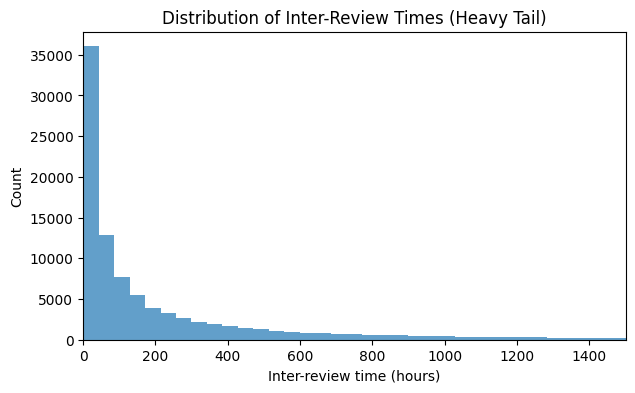

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,4))
plt.hist(df_sup['y_hours'], bins=100, alpha=0.7)
plt.xlabel("Inter-review time (hours)")
plt.ylabel("Count")
plt.title("Distribution of Inter-Review Times (Heavy Tail)")
plt.xlim(0, 1500)
plt.show()

Mean (days):   10.15
Median (days): 3.16


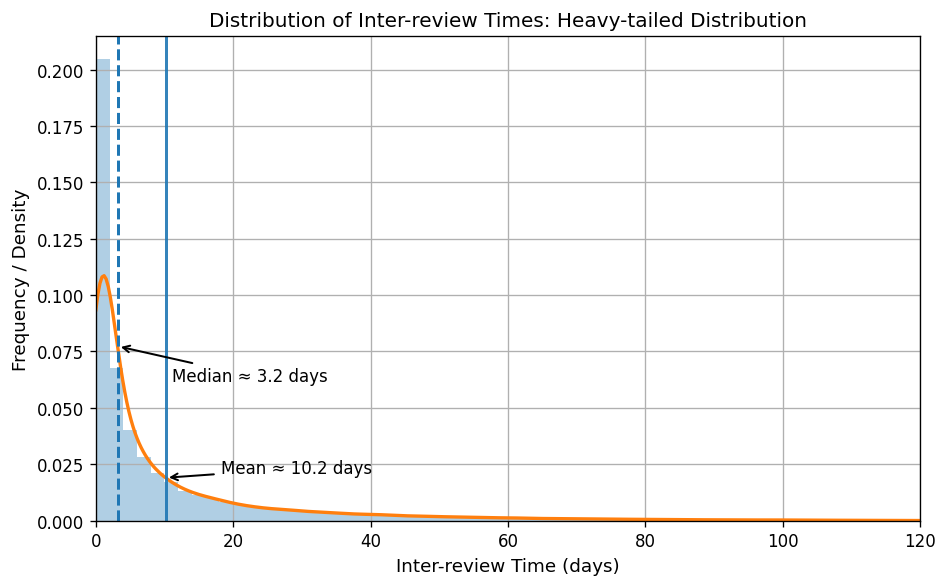

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde  # for the smooth density curve

y_hours = df_sup['y_hours'].to_numpy()
y_days = y_hours / 24.0

# For visualization, clip to at most 120 days
max_days = 120
mask = y_days <= max_days
y_days_clip = y_days[mask]

mean_days = np.mean(y_days_clip)
median_days = np.median(y_days_clip)

print(f"Mean (days):   {mean_days:.2f}")
print(f"Median (days): {median_days:.2f}")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

# Histogram normalized as density
ax.hist(
    y_days_clip,
    bins=60,
    density=True,
    alpha=0.35,
    edgecolor='none'
)

# Smooth density curve using KDE
xs = np.linspace(0, max_days, 400)
kde = gaussian_kde(y_days_clip)
ax.plot(xs, kde(xs), linewidth=2.0)

# Vertical lines for median and mean
ax.axvline(median_days, color='tab:blue', linestyle='--', linewidth=1.8)
ax.axvline(mean_days,   color='tab:blue', linestyle='-',  linewidth=1.8, alpha=0.9)

ax.annotate(
    f"Median ≈ {median_days:.1f} days",
    xy=(median_days, kde(median_days)),
    xytext=(median_days + 8, kde(median_days) * 0.8),
    arrowprops=dict(arrowstyle="->", color='black', lw=1.2),
    fontsize=10
)

ax.annotate(
    f"Mean ≈ {mean_days:.1f} days",
    xy=(mean_days, kde(mean_days)),
    xytext=(mean_days + 8, kde(mean_days) * 1.1),
    arrowprops=dict(arrowstyle="->", color='black', lw=1.2),
    fontsize=10
)

ax.set_title("Distribution of Inter-review Times: Heavy-tailed Distribution", fontsize=12)
ax.set_xlabel("Inter-review Time (days)", fontsize=11)
ax.set_ylabel("Frequency / Density", fontsize=11)

ax.set_xlim(0, max_days)

plt.tight_layout()
plt.grid(True)
plt.show()


Mean (days):   10.15
Median (days): 3.16


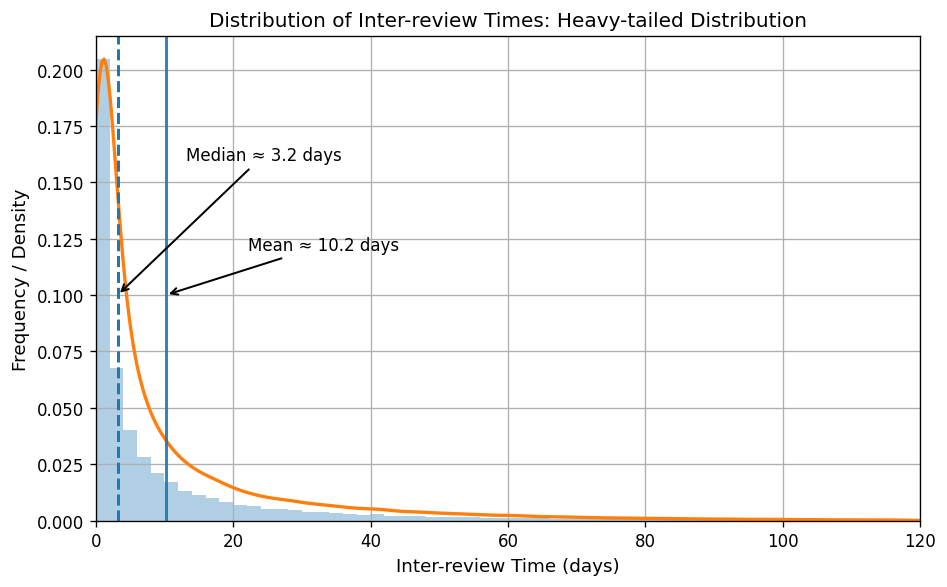

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

y_hours = df_sup['y_hours'].to_numpy()
y_days = y_hours / 24.0

max_days = 120
mask = y_days <= max_days
y_days_clip = y_days[mask]

mean_days = np.mean(y_days_clip)
median_days = np.median(y_days_clip)
print(f"Mean (days):   {mean_days:.2f}")
print(f"Median (days): {median_days:.2f}")

fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

# Histogram (get the heights back)
counts, bin_edges, _ = ax.hist(
    y_days_clip,
    bins=60,
    density=True,
    alpha=0.35,
    edgecolor='none'
)

# KDE
xs = np.linspace(0, max_days, 400)
kde = gaussian_kde(y_days_clip)
kde_vals = kde(xs)

# Rescale KDE to match histogram peak (optional cosmetic tweak)
scale_factor = counts.max() / kde_vals.max()
kde_vals_scaled = kde_vals * scale_factor

ax.plot(xs, kde_vals_scaled, linewidth=2.0)

# Median & mean lines
ax.axvline(median_days, color='tab:blue', linestyle='--', linewidth=1.8)
ax.axvline(mean_days,   color='tab:blue', linestyle='-',  linewidth=1.8, alpha=0.9)

arrow_height = 0.1

ax.annotate(
    f"Median ≈ {median_days:.1f} days",
    xy=(median_days, arrow_height),
    xytext=(median_days + 10, arrow_height + 0.06),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10
)

ax.annotate(
    f"Mean ≈ {mean_days:.1f} days",
    xy=(mean_days, arrow_height),
    xytext=(mean_days + 12, arrow_height + 0.02),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10
)

ax.set_title("Distribution of Inter-review Times: Heavy-tailed Distribution", fontsize=12)
ax.set_xlabel("Inter-review Time (days)", fontsize=11)
ax.set_ylabel("Frequency / Density", fontsize=11)
ax.set_xlim(0, max_days)

plt.tight_layout()
plt.grid(True)
plt.show()


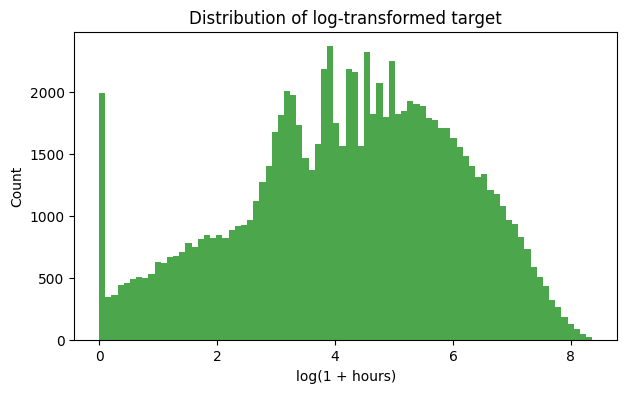

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df_sup['y_log'], bins=80, alpha=0.7, color='green')
plt.xlabel("log(1 + hours)")
plt.ylabel("Count")
plt.title("Distribution of log-transformed target")
plt.show()